In [2]:
!pip install spacy 

  Obtaining dependency information for spacy from https://files.pythonhosted.org/packages/26/3d/0bd7d780642635e662b32fcd530ed5bed1844dbf977bc5eed43efefa034c/spacy-3.8.13-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for spacy-legacy<3.1.0,>=3.0.11 from https://files.pythonhosted.org/packages/c3/55/12e842c70ff8828e34e543a2c7176dac4da006ca6901c9e8b43efab8bc6b/spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata
  Obtaining dependency information for spacy-loggers<2.0.0,>=1.0.0 from https://files.pythonhosted.org/packages/33/78/d1a1a026ef3af911159398c939b1509d5c36fe524c7b644f34a5146c4e16/spacy_loggers-1.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for murmurhash<1.1.0,>=0.28.0 from https://files.pythonhosted.org/packages/82/ed/812103a7f353eba2d83655b08205e13a38c93b4db0692f94756e1eb44516/murmurhash-1.0.15-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for cymem<2.1.0,>=2.0.2 from https://files.pythonhosted.org/packages/21/0f/f

In [4]:
!python -m spacy download en_core_web_sm

C:\Users\Komal\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 187.9 kB/s eta 0:01:08
     --------------------------------------- 0.0/12.8 MB 187.9 kB/s eta 0:01:08
     --------------------------------------- 0.1/12.8 MB 252.2 kB/s eta 0:00:51
     --------------------------------------- 0.1/12.8 MB 425.1 kB/s eta 0:00:30
      -------------------------------------- 0.2/12.8 MB 593.2 kB/s eta 0:00:22
      -------------------------------------- 0.3/12.8 MB 682.7 kB/s eta 0:00:19
     - ------------------------------------- 0.4/12.8 MB 849.3 kB/s eta 0:00:15
     - ------------------------------------- 0.5/12.8 MB 909.8 kB/s eta 0:00:14

In [5]:
!pip install seaborn wordcloud matplotlib

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   -- ------------------------------------ 20.5/306.1 kB 162.5 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/306.1 kB 245.8 kB/s eta 0:00:02
   --------- ----------------------------- 71.7/306.1 kB 391.3 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/306.1 kB 610.0 kB/s eta 0:00:01
   -------------------------- ----------- 215.0/306.1 kB 819.2 kB/s eta 0:00:01
   -------------------------------------- 306.1/306.1 kB 945.1 kB/s eta 0:00:00


In [1]:
# --- 1. Imports ---
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

C:\Users\Komal\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
df = pd.read_csv(r"C:\Users\Komal\Downloads\Koms_placement\Project\Smart Clinical Notes Analysis Using NLP\mtsamples.csv", 
                 engine='python', on_bad_lines='skip')
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (4999, 6)
   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female 

In [3]:
# --- 3. Load NLP model ---
nlp = spacy.load("en_core_web_sm")

In [4]:
# --- 4. Define keywords for demo ---
medical_keywords = ["fever", "cough", "headache", "chest pain",
                    "shortness of breath", "diabetes", "fatigue", "cancer",
                    "infection", "pain", "dizziness", "nausea"]

In [5]:
# --- 5. Function to extract medical terms from a note ---
def extract_terms(note):
    note_lower = str(note).lower()
    terms_found = []
    for word in medical_keywords:
        if word in note_lower:
            terms_found.append(word)
    return terms_found

In [6]:
# --- 6. Extract terms from dataset ---
df['Extracted_Terms'] = df['transcription'].apply(extract_terms)

In [7]:
# --- 7. User-provided notes ---
new_notes = [
    "Patient complains of abdominal pain and vomiting after eating, possible food poisoning",
    "Reports blurred vision and frequent headaches, possible migraine or eye strain",
    "Experiencing chest tightness and coughing at night, could be asthma",
    "Patient has high fever, body ache, and sore throat, suspected viral infection",
    "Complains of burning sensation while urinating, possible urinary tract infection",
    "Reports back pain and stiffness in the morning, possible muscle strain",
    "Patient reports sadness, loss of interest, and low energy, possible depression",
    "Experiencing pain in the lower abdomen and irregular periods, possible hormonal issue",
    "Reports shortness of breath and swelling in legs, may indicate heart failure",
    "Patient complains of severe headache and confusion, possible brain infection"
]


# Extract terms from user notes
new_terms = [extract_terms(note) for note in new_notes]

# Create DataFrame for user notes
user_df = pd.DataFrame({
    "Clinical_Note": new_notes,
    "Extracted_Terms": new_terms
})

In [8]:
# --- 8. Combine dataset terms and user notes terms for frequency analysis ---
all_terms = [term for sublist in df['Extracted_Terms'] for term in sublist] + \
            [term for sublist in new_terms for term in sublist]

term_counts = Counter(all_terms)
term_df = pd.DataFrame(term_counts.items(), columns=['Term', 'Frequency']).sort_values(by='Frequency', ascending=False)

In [9]:
from tabulate import tabulate
# Print user_df in table format
print(tabulate(user_df, headers='keys', tablefmt='grid'))

+----+----------------------------------------------------------------------------------------+---------------------------+
|    | Clinical_Note                                                                          | Extracted_Terms           |
+====+========================================================================================+===========================+
|  0 | Patient complains of abdominal pain and vomiting after eating, possible food poisoning | ['pain']                  |
+----+----------------------------------------------------------------------------------------+---------------------------+
|  1 | Reports blurred vision and frequent headaches, possible migraine or eye strain         | ['headache']              |
+----+----------------------------------------------------------------------------------------+---------------------------+
|  2 | Experiencing chest tightness and coughing at night, could be asthma                    | ['cough']                 |
+----+--

C:\Users\Komal\AppData\Local\Temp\ipykernel_1104\689090449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Term', y='Frequency', data=term_df.head(10), palette='Set2')


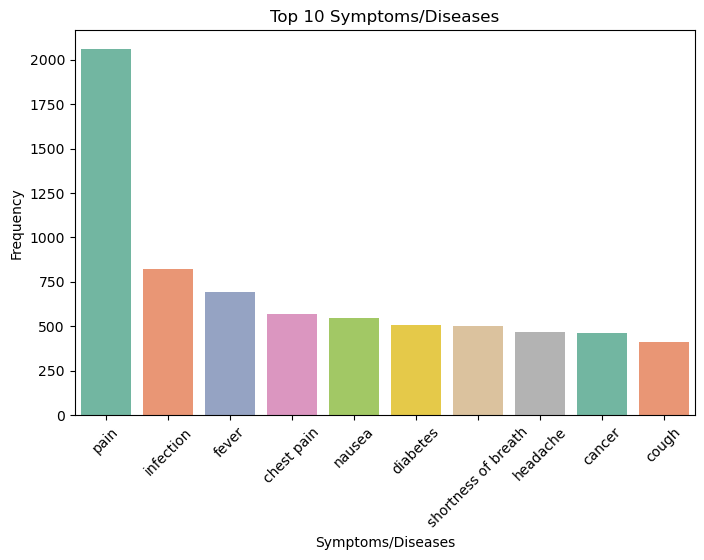

In [10]:
# --- 8. Question 1: Most common symptoms/diseases (Bar Chart) ---
plt.figure(figsize=(8,5))
sns.barplot(x='Term', y='Frequency', data=term_df.head(10), palette='Set2')
plt.title("Top 10 Symptoms/Diseases")
plt.xlabel("Symptoms/Diseases")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

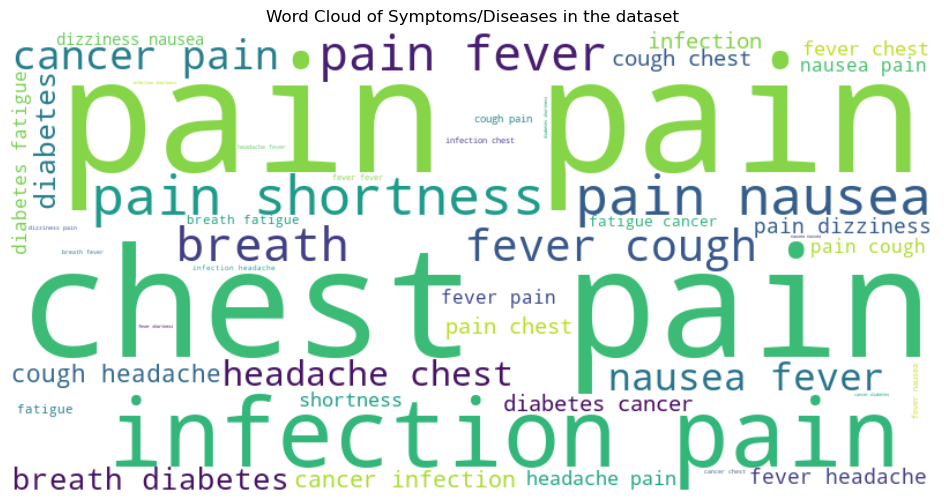

In [11]:
# --- 10. Question 3: Visual prominence (Word Cloud) ---
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(" ".join(all_terms))
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Symptoms/Diseases in the dataset")
plt.show()

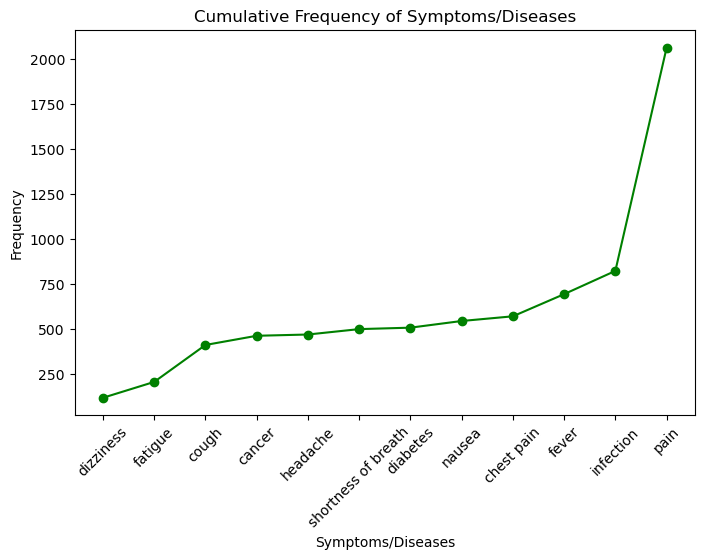

In [12]:
# --- 12. Question 5: Cumulative frequency line chart ---
sorted_terms = dict(sorted(term_counts.items(), key=lambda item: item[1]))
plt.figure(figsize=(8,5))
plt.plot(list(sorted_terms.keys()), list(sorted_terms.values()), marker='o', color='green')
plt.title("Cumulative Frequency of Symptoms/Diseases")
plt.xlabel("Symptoms/Diseases")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

Strongly Correlated Symptom Pairs (Correlation >= 0.5):
    Symptom 1            Symptom 2  Correlation
0  chest pain  shortness of breath     0.604196


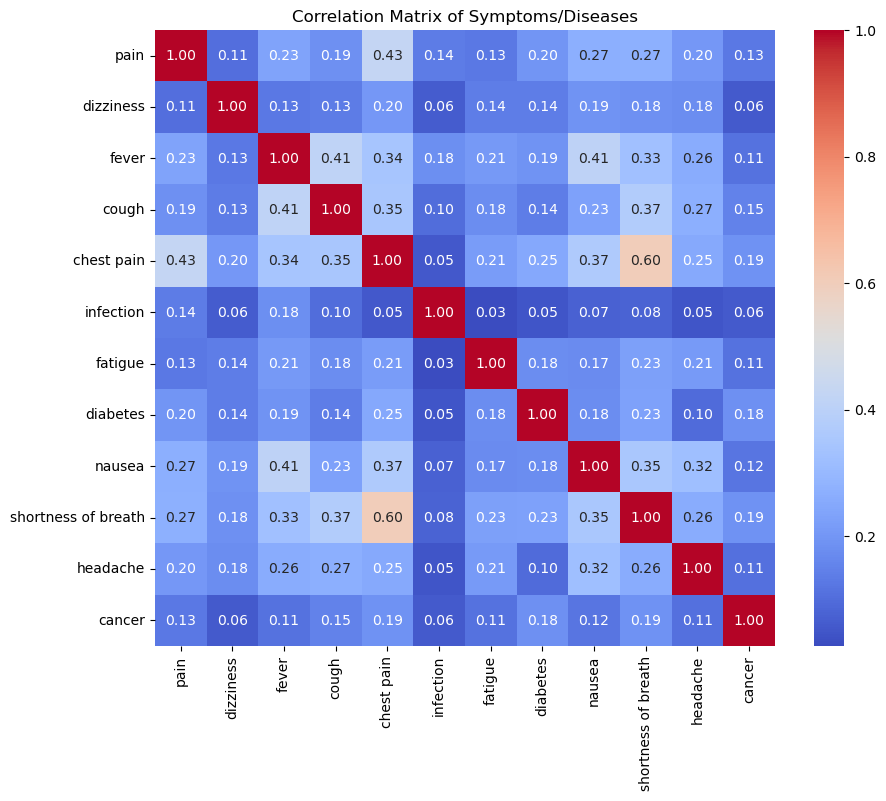

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Combine dataset and user notes ---
combined_notes = pd.concat([
    df[['transcription', 'Extracted_Terms']].rename(columns={'transcription':'Clinical_Note'}),
    user_df[['Clinical_Note', 'Extracted_Terms']]
], ignore_index=True)

# --- Create binary matrix ---
all_terms_list = list(set([term for sublist in combined_notes['Extracted_Terms'] for term in sublist]))
binary_matrix = pd.DataFrame(0, index=combined_notes.index, columns=all_terms_list)

for i, terms in enumerate(combined_notes['Extracted_Terms']):
    for term in terms:
        binary_matrix.at[i, term] = 1

# --- Compute correlation matrix ---
corr_matrix = binary_matrix.corr()

# --- Find strongly correlated symptom pairs (correlation >= 0.5, ignore self-correlation) ---
strong_corr = []
threshold = 0.5
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and corr_matrix.loc[i,j] >= threshold:
            strong_corr.append((i, j, corr_matrix.loc[i,j]))

# Remove duplicate pairs (A-B same as B-A)
unique_corr = []
seen = set()
for a,b,c in strong_corr:
    if (b,a) not in seen:
        unique_corr.append((a,b,c))
        seen.add((a,b))

# --- Display strong correlations ---
strong_corr_df = pd.DataFrame(unique_corr, columns=['Symptom 1', 'Symptom 2', 'Correlation'])
print("Strongly Correlated Symptom Pairs (Correlation >= 0.5):")
print(strong_corr_df)

# --- Optional: Heatmap for visual reference ---
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Matrix of Symptoms/Diseases")
plt.show()


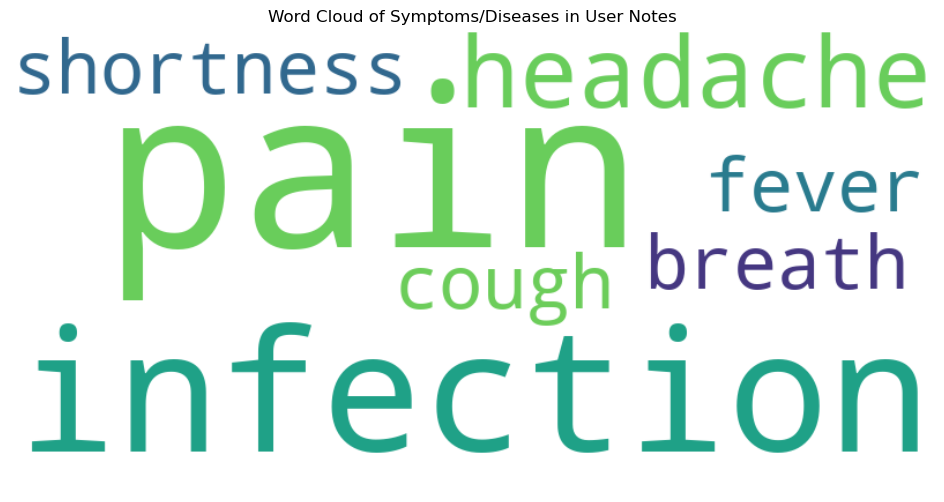

In [14]:
# --- Word Cloud for User Notes ---
# Flatten the list of extracted terms from user notes
user_terms_flat = [term for sublist in new_terms for term in sublist]
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(" ".join(user_terms_flat))
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Symptoms/Diseases in User Notes")
plt.show()
